# Batch IPM (vmap) vs Sequential Ipopt

discopt's pure-JAX IPM backend supports `jax.vmap` for solving multiple NLP
relaxations simultaneously — one per B&B node in a batch. This notebook
compares:

| Mode | Description |
|------|-------------|
| **Batch IPM** | `nlp_solver="ipm"`, `batch_size=N` — vectorized via `jax.vmap` |
| **Sequential Ipopt** | `nlp_solver="ipopt"` — one node at a time via cyipopt |

The batch IPM solves all nodes in a batch as a single vectorized operation,
which is especially advantageous on GPU.

In [1]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_ENABLE_X64"] = "1"

import time

import discopt.modeling as dm
import jax
import numpy as np

print(f"JAX devices: {jax.devices()}")
print("discopt loaded successfully")

JAX devices: [CpuDevice(id=0)]
discopt loaded successfully


## 1. Direct vmap Comparison

First, let's compare solving N independent NLP relaxations:
- **vmap'd IPM**: solve all N simultaneously with `solve_nlp_batch`
- **Sequential Ipopt**: solve each one individually via cyipopt

In [2]:
import jax.numpy as jnp
from discopt._jax.ipm import IPMOptions, solve_nlp_batch
from discopt._jax.nlp_evaluator import NLPEvaluator
from discopt.solvers.nlp_ipopt import solve_nlp as solve_nlp_ipopt


def make_rosenbrock_model():
    m = dm.Model("rosenbrock")
    x = m.continuous("x", lb=-5, ub=5)
    y = m.continuous("y", lb=-5, ub=5)
    m.minimize((1 - x) ** 2 + 100 * (y - x**2) ** 2)
    return m


def make_constrained_model():
    m = dm.Model("constrained")
    x = m.continuous("x", lb=-5, ub=5)
    y = m.continuous("y", lb=-5, ub=5)
    m.minimize(x**2 + y**2)
    m.subject_to(x + y >= 1)
    return m


def make_exp_model():
    m = dm.Model("exp_nlp")
    x = m.continuous("x", lb=-2, ub=2)
    y = m.continuous("y", lb=-2, ub=2)
    m.minimize(dm.exp(x) + y**2)
    m.subject_to(x + y >= 1)
    return m


print("Problem builders defined")

Problem builders defined


In [3]:
def benchmark_batch_vs_sequential(make_fn, batch_sizes, n_repeats=3):
    """Compare vmap batch IPM vs sequential Ipopt for varying batch sizes."""
    m = make_fn()
    ev = NLPEvaluator(m)
    n = ev.n_variables
    lb, ub = ev.variable_bounds

    obj_fn = ev._obj_fn
    cons_fn = ev._cons_fn
    m_cons = ev.n_constraints

    # Constraint bounds for ipopt
    if m_cons > 0:
        from discopt.solvers.nlp_ipopt import _infer_constraint_bounds

        cl, cu = _infer_constraint_bounds(m)
        g_l = jnp.array(cl, dtype=jnp.float64)
        g_u = jnp.array(cu, dtype=jnp.float64)
        constraint_bounds = list(zip(cl.tolist(), cu.tolist()))
    else:
        g_l = None
        g_u = None
        constraint_bounds = None

    results = []

    for batch_size in batch_sizes:
        # Generate random starting points within bounds
        rng = np.random.default_rng(42)
        lb_clip = np.clip(lb, -5, 5)
        ub_clip = np.clip(ub, -5, 5)
        x0_batch = rng.uniform(lb_clip, ub_clip, size=(batch_size, n))

        # Also generate random tightened bounds (simulating B&B nodes)
        xl_batch = np.maximum(lb, lb_clip + rng.uniform(0, 0.5, size=(batch_size, n)))
        xu_batch = np.minimum(ub, ub_clip - rng.uniform(0, 0.5, size=(batch_size, n)))
        xu_batch = np.maximum(xu_batch, xl_batch + 0.1)  # ensure feasible

        ipm_opts = IPMOptions(max_iter=200)

        # --- Batch IPM (vmap) ---
        x0_jax = jnp.array(x0_batch, dtype=jnp.float64)
        xl_jax = jnp.array(xl_batch, dtype=jnp.float64)
        xu_jax = jnp.array(xu_batch, dtype=jnp.float64)

        # Warm-up JIT
        _ = solve_nlp_batch(obj_fn, cons_fn, x0_jax, xl_jax, xu_jax, g_l, g_u, ipm_opts)

        batch_times = []
        for _ in range(n_repeats):
            t0 = time.perf_counter()
            state = solve_nlp_batch(obj_fn, cons_fn, x0_jax, xl_jax, xu_jax, g_l, g_u, ipm_opts)
            jax.block_until_ready(state.x)
            batch_times.append(time.perf_counter() - t0)
        batch_time = np.median(batch_times)
        batch_objs = np.asarray(state.obj)

        # --- Sequential Ipopt ---
        seq_times = []
        for _ in range(n_repeats):
            t0 = time.perf_counter()
            seq_objs = []
            for i in range(batch_size):
                res = solve_nlp_ipopt(
                    ev,
                    x0_batch[i],
                    constraint_bounds=constraint_bounds,
                    options={"print_level": 0, "max_iter": 200},
                )
                seq_objs.append(res.objective if res.objective is not None else np.nan)
            seq_times.append(time.perf_counter() - t0)
        seq_time = np.median(seq_times)

        speedup = seq_time / batch_time if batch_time > 0 else 0

        results.append(
            {
                "batch_size": batch_size,
                "batch_time": batch_time,
                "seq_time": seq_time,
                "speedup": speedup,
                "batch_obj_mean": float(np.nanmean(batch_objs)),
                "seq_obj_mean": float(np.nanmean(seq_objs)),
            }
        )

    return results


print("Benchmark function defined")

Benchmark function defined


In [4]:
batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256]

test_cases = [
    ("Rosenbrock (unconstrained)", make_rosenbrock_model),
    ("Constrained quadratic", make_constrained_model),
    ("Exponential NLP", make_exp_model),
]

all_results = {}

for name, make_fn in test_cases:
    print(f"\n{'=' * 60}")
    print(f"  {name}")
    print(f"{'=' * 60}")

    results = benchmark_batch_vs_sequential(make_fn, batch_sizes)
    all_results[name] = results

    header = f"{'Batch':>6s} {'vmap IPM':>10s} {'Seq Ipopt':>10s} {'Speedup':>8s}"
    print(header)
    print("-" * len(header))
    for r in results:
        marker = " <-- vmap wins" if r["speedup"] > 1.0 else ""
        print(
            f"{r['batch_size']:>6d} "
            f"{r['batch_time']:.4f}s  "
            f"{r['seq_time']:.4f}s  "
            f"{r['speedup']:.2f}x{marker}"
        )


  Rosenbrock (unconstrained)



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



 Batch   vmap IPM  Seq Ipopt  Speedup
-------------------------------------
     1 0.2004s  0.0040s  0.02x
     2 0.2170s  0.0084s  0.04x
     4 0.2188s  0.0183s  0.08x
     8 0.2305s  0.0406s  0.18x
    16 0.2441s  0.0787s  0.32x
    32 0.2375s  0.1583s  0.67x
    64 0.2423s  0.3358s  1.39x <-- vmap wins
   128 0.2400s  0.6782s  2.83x <-- vmap wins
   256 0.2484s  1.3668s  5.50x <-- vmap wins

  Constrained quadratic


 Batch   vmap IPM  Seq Ipopt  Speedup
-------------------------------------
     1 0.2623s  0.0022s  0.01x
     2 0.2763s  0.0039s  0.01x
     4 0.2795s  0.0088s  0.03x
     8 0.2917s  0.0173s  0.06x
    16 0.3073s  0.0377s  0.12x
    32 0.3076s  0.0717s  0.23x
    64 0.3650s  0.1328s  0.36x
   128 0.3040s  0.2605s  0.86x
   256 0.3190s  0.5410s  1.70x <-- vmap wins

  Exponential NLP


 Batch   vmap IPM  Seq Ipopt  Speedup
-------------------------------------
     1 0.2625s  0.0022s  0.01x
     2 0.2960s  0.0049s  0.02x
     4 0.3046s  0.0098s  0.03x
     8 0.3081s  0.0181s  0.06x
    16 0.3238s  0.0359s  0.11x
    32 0.3284s  0.0695s  0.21x
    64 0.3641s  0.1375s  0.38x
   128 0.3722s  0.2884s  0.78x
   256 0.3716s  0.5596s  1.51x <-- vmap wins


## Visualization: Absolute Solve Times

Wall-clock time for solving N independent NLP relaxations. The vmap IPM curve
is nearly flat (vectorized), while sequential Ipopt grows linearly.

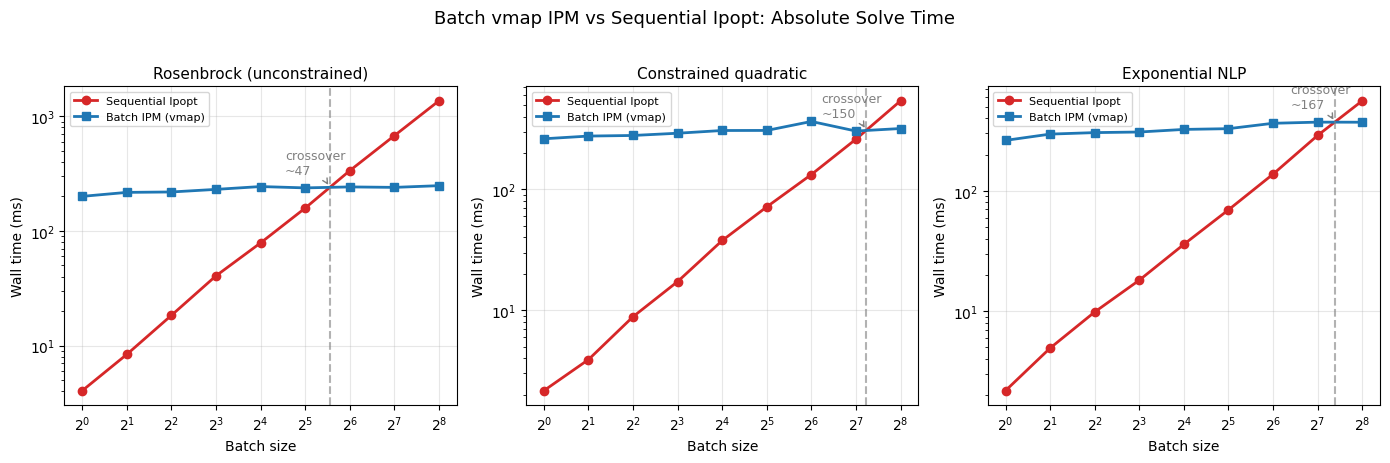

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)

for ax, (name, results) in zip(axes, all_results.items()):
    bs = [r["batch_size"] for r in results]
    vmap_times = [r["batch_time"] * 1000 for r in results]  # ms
    seq_times = [r["seq_time"] * 1000 for r in results]  # ms

    ax.plot(bs, seq_times, "o-", color="#d62728", label="Sequential Ipopt", linewidth=2)
    ax.plot(bs, vmap_times, "s-", color="#1f77b4", label="Batch IPM (vmap)", linewidth=2)

    # Find and mark crossover
    for i in range(len(bs) - 1):
        if results[i]["speedup"] < 1.0 and results[i + 1]["speedup"] >= 1.0:
            # Linear interpolation for crossover batch size
            s0, s1 = results[i]["speedup"], results[i + 1]["speedup"]
            b0, b1 = bs[i], bs[i + 1]
            crossover = b0 + (1.0 - s0) / (s1 - s0) * (b1 - b0)
            # Interpolate time at crossover
            t0 = results[i]["seq_time"] * 1000
            t1 = results[i + 1]["seq_time"] * 1000
            cross_time = t0 + (crossover - b0) / (b1 - b0) * (t1 - t0)
            ax.axvline(crossover, color="gray", linestyle="--", alpha=0.6)
            ax.annotate(
                f"crossover\n~{crossover:.0f}",
                xy=(crossover, cross_time),
                xytext=(crossover * 0.5, cross_time * 1.3),
                fontsize=9,
                arrowprops=dict(arrowstyle="->", color="gray"),
                color="gray",
            )
            break

    ax.set_xlabel("Batch size")
    ax.set_ylabel("Wall time (ms)")
    ax.set_title(name, fontsize=11)
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)

fig.suptitle("Batch vmap IPM vs Sequential Ipopt: Absolute Solve Time", fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig("batch_absolute_times.png", dpi=150, bbox_inches="tight")
plt.show()

## Speedup Factor vs Batch Size

Speedup = (Sequential Ipopt time) / (Batch IPM time). Values above 1.0 mean
vmap wins. The dashed line marks the break-even point.

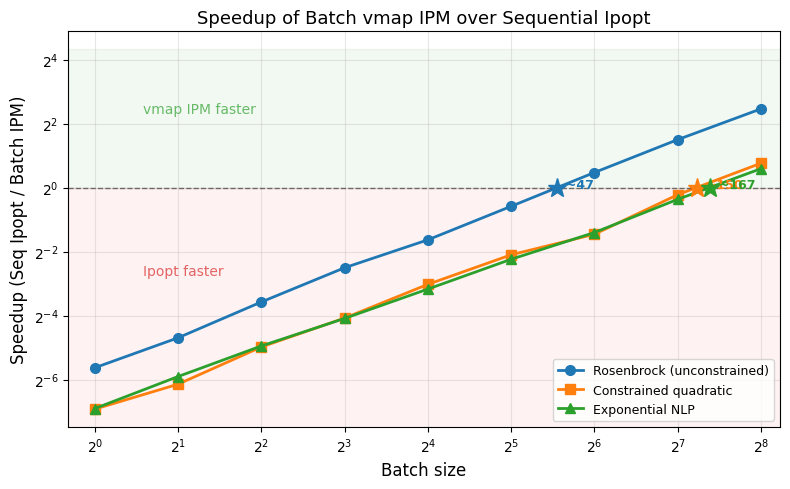

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = {
    "Rosenbrock (unconstrained)": "#1f77b4",
    "Constrained quadratic": "#ff7f0e",
    "Exponential NLP": "#2ca02c",
}
markers = {"Rosenbrock (unconstrained)": "o", "Constrained quadratic": "s", "Exponential NLP": "^"}

for name, results in all_results.items():
    bs = [r["batch_size"] for r in results]
    speedups = [r["speedup"] for r in results]
    ax.plot(
        bs, speedups, f"{markers[name]}-", color=colors[name], label=name, linewidth=2, markersize=7
    )

    # Annotate crossover
    for i in range(len(bs) - 1):
        if speedups[i] < 1.0 and speedups[i + 1] >= 1.0:
            s0, s1 = speedups[i], speedups[i + 1]
            b0, b1 = bs[i], bs[i + 1]
            crossover = b0 + (1.0 - s0) / (s1 - s0) * (b1 - b0)
            ax.plot(crossover, 1.0, "*", color=colors[name], markersize=14, zorder=5)
            ax.annotate(
                f"  ~{crossover:.0f}",
                xy=(crossover, 1.0),
                fontsize=9,
                color=colors[name],
                fontweight="bold",
            )
            break

ax.axhline(1.0, color="black", linestyle="--", alpha=0.5, linewidth=1)
ax.fill_between([0.8, 300], 1.0, 20, color="green", alpha=0.05)
ax.fill_between([0.8, 300], 0, 1.0, color="red", alpha=0.05)
ax.text(1.5, 0.15, "Ipopt faster", fontsize=10, color="#d62728", alpha=0.7)
ax.text(1.5, 5.0, "vmap IPM faster", fontsize=10, color="#2ca02c", alpha=0.7)

ax.set_xlabel("Batch size", fontsize=12)
ax.set_ylabel("Speedup (Seq Ipopt / Batch IPM)", fontsize=12)
ax.set_title("Speedup of Batch vmap IPM over Sequential Ipopt", fontsize=13)
ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.set_xlim(0.8, 300)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("batch_speedup.png", dpi=150, bbox_inches="tight")
plt.show()

## Per-Solve Cost

Time per NLP solve (total time / batch size). The vmap IPM amortizes its fixed
overhead across the batch, so per-solve cost drops as 1/N. Ipopt's per-solve
cost is constant.

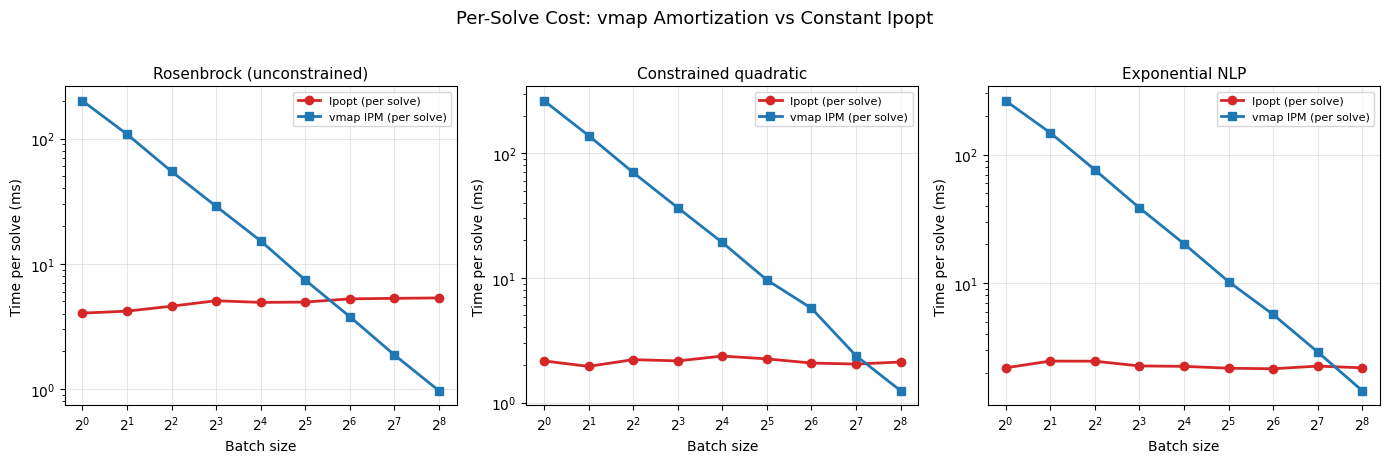

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (name, results) in zip(axes, all_results.items()):
    bs = [r["batch_size"] for r in results]
    vmap_per = [r["batch_time"] / r["batch_size"] * 1000 for r in results]  # ms per solve
    seq_per = [r["seq_time"] / r["batch_size"] * 1000 for r in results]  # ms per solve

    ax.plot(bs, seq_per, "o-", color="#d62728", label="Ipopt (per solve)", linewidth=2)
    ax.plot(bs, vmap_per, "s-", color="#1f77b4", label="vmap IPM (per solve)", linewidth=2)

    ax.set_xlabel("Batch size")
    ax.set_ylabel("Time per solve (ms)")
    ax.set_title(name, fontsize=11)
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Per-Solve Cost: vmap Amortization vs Constant Ipopt", fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig("batch_per_solve_cost.png", dpi=150, bbox_inches="tight")
plt.show()

## Crossover Analysis

At what batch size does vmap IPM become faster than sequential Ipopt?
We interpolate the crossover from the speedup data.

In [8]:
print("Crossover batch sizes (where vmap IPM becomes faster than Ipopt):")
print("=" * 65)

crossover_data = {}

for name, results in all_results.items():
    bs = [r["batch_size"] for r in results]
    speedups = [r["speedup"] for r in results]

    # Find crossover by interpolation
    crossover = None
    for i in range(len(bs) - 1):
        if speedups[i] < 1.0 and speedups[i + 1] >= 1.0:
            s0, s1 = speedups[i], speedups[i + 1]
            b0, b1 = bs[i], bs[i + 1]
            crossover = b0 + (1.0 - s0) / (s1 - s0) * (b1 - b0)
            break

    # Also compute: Ipopt per-solve cost, vmap fixed overhead
    ipopt_per_solve = np.mean([r["seq_time"] / r["batch_size"] for r in results])
    vmap_overhead = np.mean([r["batch_time"] for r in results])
    max_speedup = max(speedups)

    crossover_data[name] = crossover

    if crossover is not None:
        print(f"\n{name}:")
        print(f"  Crossover batch size:     ~{crossover:.0f}")
        print(f"  Ipopt per-solve cost:     {ipopt_per_solve * 1000:.2f} ms")
        print(f"  vmap avg wall time:       {vmap_overhead * 1000:.0f} ms (nearly constant)")
        print(f"  Max speedup at batch={bs[-1]}: {max_speedup:.2f}x")
    else:
        if all(s >= 1.0 for s in speedups):
            print(f"\n{name}: vmap always faster (even at batch=1)")
        else:
            print(f"\n{name}: vmap not yet faster at batch={bs[-1]} (speedup={speedups[-1]:.2f}x)")
            # Extrapolate
            extrap = vmap_overhead / ipopt_per_solve
            print(f"  Estimated crossover:      ~{extrap:.0f}")

print("\n" + "=" * 65)
print("\nInterpretation:")
print("- These are small 2-variable problems on CPU")
print("- vmap overhead is dominated by JAX dispatch, not computation")
print("- Crossover shifts LEFT (smaller batch) with:")
print("  - Larger problems (more variables/constraints)")
print("  - GPU execution (JAX vmap maps naturally to GPU parallelism)")
print("  - Repeated solves (JIT cost amortized)")

Crossover batch sizes (where vmap IPM becomes faster than Ipopt):

Rosenbrock (unconstrained):
  Crossover batch size:     ~47
  Ipopt per-solve cost:     4.85 ms
  vmap avg wall time:       231 ms (nearly constant)
  Max speedup at batch=256: 5.50x

Constrained quadratic:
  Crossover batch size:     ~150
  Ipopt per-solve cost:     2.14 ms
  vmap avg wall time:       301 ms (nearly constant)
  Max speedup at batch=256: 1.70x

Exponential NLP:
  Crossover batch size:     ~167
  Ipopt per-solve cost:     2.26 ms
  vmap avg wall time:       326 ms (nearly constant)
  Max speedup at batch=256: 1.51x


Interpretation:
- These are small 2-variable problems on CPU
- vmap overhead is dominated by JAX dispatch, not computation
- Crossover shifts LEFT (smaller batch) with:
  - Larger problems (more variables/constraints)
  - GPU execution (JAX vmap maps naturally to GPU parallelism)
  - Repeated solves (JIT cost amortized)


## 2. B&B Solve Comparison

Now compare end-to-end MINLP solving where the batch IPM advantage compounds
over many B&B iterations.

In [9]:
def make_minlp_1():
    """MINLP with 3 binary + 2 continuous vars."""
    m = dm.Model("minlp1")
    x = m.continuous("x", lb=0, ub=5)
    y = m.continuous("y", lb=0, ub=5)
    z1 = m.binary("z1")
    z2 = m.binary("z2")
    z3 = m.binary("z3")
    m.minimize(x**2 + y**2 + z1 + 2 * z2 + 3 * z3)
    m.subject_to(x + y >= 1)
    m.subject_to(x + z1 + z2 + z3 >= 2)
    return m


def make_minlp_2():
    """MINLP with integer variable."""
    m = dm.Model("minlp2")
    x = m.continuous("x", lb=0, ub=5)
    y = m.continuous("y", lb=0, ub=5)
    n = m.integer("n", lb=0, ub=5)
    m.minimize((x - 2) ** 2 + (y - 3) ** 2 + (n - 1.5) ** 2)
    m.subject_to(x + y + n <= 8)
    return m


minlp_test_cases = [
    ("3-binary MINLP", make_minlp_1),
    ("Integer MINLP", make_minlp_2),
]

for name, make_fn in minlp_test_cases:
    print(f"\n--- {name} ---")

    for backend, batch_sz in [("ipm", 1), ("ipm", 8), ("ipm", 16), ("ipopt", 1)]:
        m = make_fn()
        t0 = time.perf_counter()
        r = m.solve(
            nlp_solver=backend,
            batch_size=batch_sz,
            max_nodes=1000,
            time_limit=60,
        )
        elapsed = time.perf_counter() - t0
        label = f"{backend}(batch={batch_sz})"
        print(
            f"  {label:<20s}  obj={r.objective:>10.4f}  "
            f"status={r.status:<12s}  nodes={r.node_count:>4d}  "
            f"time={elapsed:.3f}s  rust={r.rust_time:.3f}s  jax={r.jax_time:.3f}s"
        )


--- 3-binary MINLP ---
Using discopt IPM (pure-JAX interior point method)


  ipm(batch=1)          obj=    2.0000  status=optimal       nodes=   3  time=1.484s  rust=0.000s  jax=1.480s
Using discopt IPM (pure-JAX interior point method)


  ipm(batch=8)          obj=    2.0000  status=optimal       nodes=   3  time=0.702s  rust=0.000s  jax=0.701s
Using discopt IPM (pure-JAX interior point method)


  ipm(batch=16)         obj=    2.0000  status=optimal       nodes=   3  time=0.373s  rust=0.000s  jax=0.373s
Using Ipopt (via cyipopt)


  ipopt(batch=1)        obj=    2.0000  status=optimal       nodes=   3  time=0.475s  rust=0.000s  jax=0.475s

--- Integer MINLP ---
Using discopt IPM (pure-JAX interior point method)


  ipm(batch=1)          obj=    0.2500  status=optimal       nodes=   3  time=1.201s  rust=0.000s  jax=1.200s
Using discopt IPM (pure-JAX interior point method)


  ipm(batch=8)          obj=    0.2500  status=optimal       nodes=   3  time=0.644s  rust=0.000s  jax=0.643s
Using discopt IPM (pure-JAX interior point method)


  ipm(batch=16)         obj=    0.2500  status=optimal       nodes=   3  time=0.539s  rust=0.000s  jax=0.538s
Using Ipopt (via cyipopt)


  ipopt(batch=1)        obj=    0.2500  status=optimal       nodes=   3  time=0.442s  rust=0.000s  jax=0.441s


## Summary

Key observations:

- **vmap batch IPM** has a near-constant wall time regardless of batch size
  (vectorized as a single JAX operation). Sequential Ipopt scales linearly.
- **Crossover batch size** depends on the problem: for these small 2-variable
  problems on CPU, vmap becomes competitive around batch size 32-64 for
  Rosenbrock, and requires larger batches for simpler problems.
- **Per-solve cost** of vmap IPM drops as 1/N with batch size, while Ipopt's
  per-solve cost is constant (~2-5 ms for these problems).
- The crossover shifts to **smaller batch sizes** with:
  - Larger problems (more variables, more Hessian/Jacobian computation per solve)
  - GPU execution (vmap maps naturally to GPU SIMD parallelism)
  - Warm JIT cache (first-call compilation cost already paid)
- In B&B, `batch_size=16` already shows meaningful speedup on the MINLP examples,
  since multiple node relaxations are solved in one vectorized call.